In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

In [2]:

cols = ['CreditScore','Geography','Gender','Age','Tenure',
        'Balance','NumOfProducts','IsActiveMember','EstimatedSalary','Exited']

churn = pd.read_csv(
    r"C:\\Users\\LENOVO\\Downloads\\archive (2)\\Churn_Modelling.csv",
    usecols=cols
)
churn.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,79084.10,0


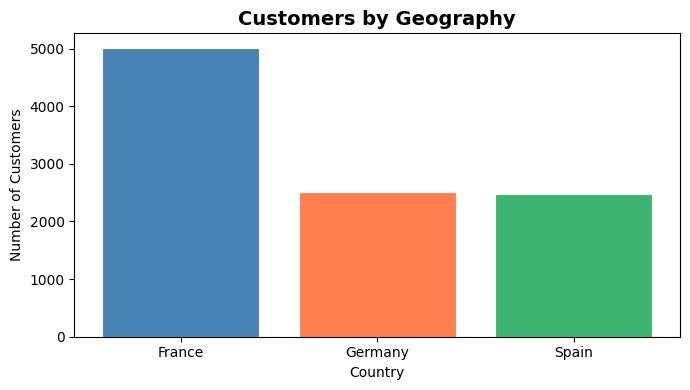

In [3]:
geo_counts = churn['Geography'].value_counts()

plt.figure(figsize=(7, 4))
bars = plt.bar(geo_counts.index, geo_counts.values,
               color=['steelblue', 'coral', 'mediumseagreen'],
               edgecolor='white', linewidth=0.8)

plt.title('Customers by Geography', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

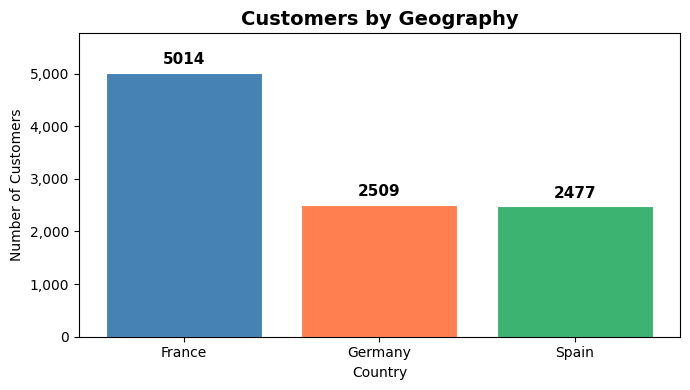

In [4]:
geo_counts = churn['Geography'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(geo_counts.index, geo_counts.values,
              color=['steelblue', 'coral', 'mediumseagreen'],
              edgecolor='white', linewidth=0.8)

ax.bar_label(bars, fmt='%d', padding=4, fontsize=11, fontweight='bold')

ax.set_title('Customers by Geography', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, geo_counts.max() * 1.15)   # headroom for labels
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

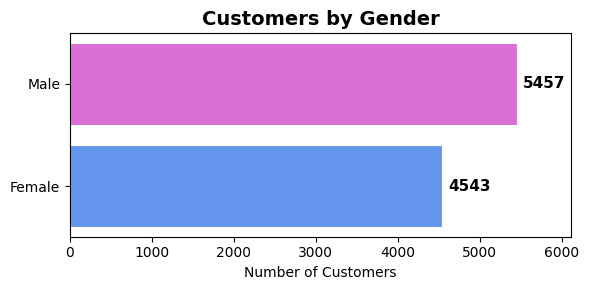

In [5]:
gender_counts = churn['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(gender_counts.index, gender_counts.values,
               color=['orchid', 'cornflowerblue'],
               edgecolor='white', linewidth=0.8)

ax.bar_label(bars, fmt='%d', padding=4, fontsize=11, fontweight='bold')
ax.set_title('Customers by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Customers')
ax.invert_yaxis()   # largest bar on top
ax.set_xlim(0, gender_counts.max() * 1.12)

plt.tight_layout()
plt.show()

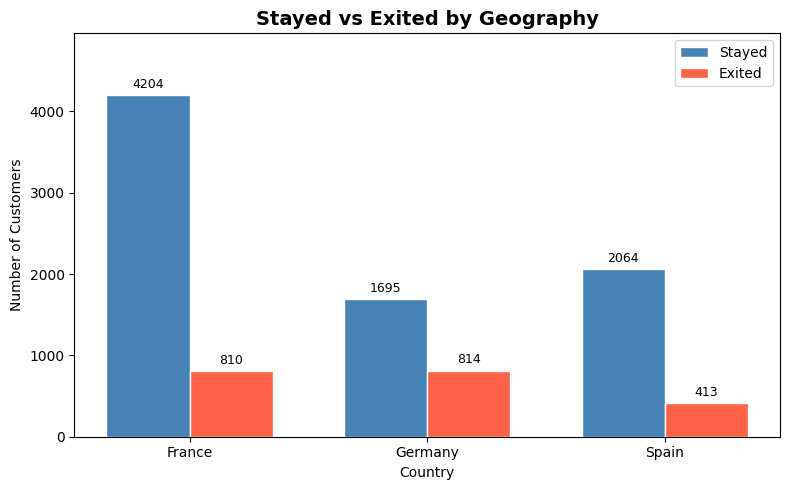

In [6]:
group = churn.groupby(['Geography', 'Exited']).size().unstack(fill_value=0)
group.columns = ['Stayed', 'Exited']

countries = group.index.tolist()
x = np.arange(len(countries))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, group['Stayed'], width, label='Stayed',
            color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, group['Exited'], width, label='Exited',
            color='tomato', edgecolor='white')

ax.bar_label(b1, fmt='%d', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%d', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.set_title('Stayed vs Exited by Geography', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Customers')
ax.legend()
ax.set_ylim(0, group.max().max() * 1.18)

plt.tight_layout()
plt.show()